In [ ]:
##Different Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from functionsFolder.config import text_data, biometric_data, adv_to_del, team_to_del, id, useless, index, to_keep
from functionsFolder.preProcessingAuto import preprocess_working_df
from functionsFolder.modelAutomation import get_features_and_target, clean_features, evaluate_models, prepare_features
from sklearn.feature_selection import SelectPercentile
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from time import time
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import joblib

# Custom MAPE function (since sklearn does not have it directly)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

##Different Paths
HOME = r"HOME"
W_DB = r"\Database\Working db"
STACK = r"\Thesis - Code\database\Database Updates\Database stack"

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Utilisateur\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Utilisateur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Utilisateur\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
base_df = pd.read_excel(r"Data\looping_df_1746884524.8275206.xlsx")
RECOVERY_OPP = r"Data\27-4-2025_team.xlsx"

In [3]:
#add the mean of every position in the advance part and scouting evaluation part
base_df[to_keep['adv']] = base_df[to_keep['adv']].fillna(base_df.groupby('Pos_x_features')[to_keep['adv']].transform('median'))
base_df[to_keep['scouting_reports']] = base_df[to_keep['scouting_reports']].fillna(base_df.groupby('Pos_x_features')[to_keep['scouting_reports']].transform('median'))
processed_df = preprocess_working_df(base_df, recovery_file=RECOVERY_OPP)
#Get a copy of the dataset
working_df = processed_df.copy()
# Get initial features and targets
raw_features, target = get_features_and_target(working_df) #Get the features and target columns' name in separate lists


# Step 2: Prepare feature list (optionally re-adding 'adv' and 'scouting_reports')
include_subsets = ['per_40', 'team', 'opp', 'adv', 'scouting_reports']
features, included_types = prepare_features( #prepare the features' space
    base_features=raw_features,
    df=working_df,
    useless_list=useless, #list of features that we do not use 
    feature_dict=to_keep, #dictionnary of the features that we keep 
    include_keys=include_subsets #the keys to the dictionnary above
)
#Change the height from feet to inches 
working_df['Height_features'] = working_df['Height_features'].apply(
    lambda x: int(x.split('-')[0]) * 12 + int(x.split('-')[1])
)

#We keep only the players that where drafted after 2009 (60 players for 15 years = 900 max)
df = working_df[working_df['draft_season_features'] > 8].copy()

#We keep context variables in an list
keywords = ['team', 'opp', 'text']
filtered_list = [element for element in features if not any(keyword in element for keyword in keywords)]

2025-05-15 12:48:35,822 - INFO - Starting full preprocessing pipeline...
2025-05-15 12:48:35,822 - INFO - Creating dummy variables...
2025-05-15 12:48:35,833 - INFO - After dummy variable creation: shape = (1253, 389)
2025-05-15 12:48:35,833 - INFO - Categorizing and one-hot encoding categorical features...
2025-05-15 12:48:35,867 - INFO - After categorization and one-hot encoding: shape = (1253, 405)
2025-05-15 12:48:35,867 - INFO - Processing unstructured text data...
2025-05-15 12:48:41,378 - INFO - After TF-IDF vectorization: shape = (1253, 8291)
2025-05-15 12:48:41,430 - INFO - After after TF-IDF merge: shape = (1253, 8696)
2025-05-15 12:48:41,434 - INFO - Imputing opponent columns based on team data...
2025-05-15 12:48:45,072 - INFO - After imputation using team data: shape = (1253, 8696)
2025-05-15 12:48:45,072 - INFO - Imputing opponent columns using recovery data...
2025-05-15 12:48:57,383 - INFO - After imputation using recovery data: shape = (1253, 8696)
2025-05-15 12:48:57,

In [10]:
i = 1
df['med_tresh'] = (df[f'WS/48-{i}_target'] > 0).astype(int)
features.append('med_tresh')
df[features].to_excel('new_df_with_tfidf.xlsx', index=False)

# Introduction

In [ ]:
##Different Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.svm import SVR  
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from functionsFolder.config import text_data, biometric_data, adv_to_del, team_to_del, id, useless, index, to_keep
from functionsFolder.preProcessingAuto import preprocess_working_df
from functionsFolder.modelAutomation import get_features_and_target, clean_features, evaluate_models, prepare_features

# Custom MAPE function (since sklearn does not have it directly)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

##Different Paths
HOME = r"HOME"
W_DB = r"\Database\Working db"
STACK = r"\Thesis - Code\database\Database Updates\Database stack"

In [ ]:
base_df = pd.read_excel(r"Data\looping_df_1745786475.4036798.xlsx")
RECOVERY_OPP = r"Data\27-4-2025_team.xlsx"

# Preprocessing

## Base preprocessing

In [3]:
#add the mean of every position in the advance part and scouting evaluation part
base_df[to_keep['adv']] = base_df[to_keep['adv']].fillna(base_df.groupby('Pos_x_features')[to_keep['adv']].transform('median'))
base_df[to_keep['scouting_reports']] = base_df[to_keep['scouting_reports']].fillna(base_df.groupby('Pos_x_features')[to_keep['scouting_reports']].transform('median'))
processed_df = preprocess_working_df(base_df, recovery_file=RECOVERY_OPP)
#Get a copy of the dataset
working_df = processed_df.copy()
# Get initial features and targets
raw_features, target = get_features_and_target(working_df) #Get the features and target columns' name in separate lists


# Step 2: Prepare feature list (optionally re-adding 'adv' and 'scouting_reports')
include_subsets = ['per_40', 'team', 'opp', 'adv', 'scouting_reports']
features, included_types = prepare_features( #prepare the features' space
    base_features=raw_features,
    df=working_df,
    useless_list=useless, #list of features that we do not use 
    feature_dict=to_keep, #dictionnary of the features that we keep 
    include_keys=include_subsets #the keys to the dictionnary above
)
#Change the height from feet to inches 
working_df['Height_features'] = working_df['Height_features'].apply(
    lambda x: int(x.split('-')[0]) * 12 + int(x.split('-')[1])
)

KeyError: "None of [Index(['Athleticism_features', 'Size_features', 'Defense_features',\n       'Strength2_features', 'Quickness_features', 'Leadership_features',\n       'Jump Shot_features', 'NBA Ready_features', 'Rebounding_features',\n       'Potential_features', 'Post Skills_features', 'Intangibles_features'],\n      dtype='object')] are in the [columns]"

In [24]:
working_df.set_index('Name_features', inplace='True')


KeyboardInterrupt



In [4]:
#We keep only the players that where drafted after 2009 (60 players for 15 years = 900 max)
df = working_df[working_df['draft_season_features'] > 8].copy()

#We keep context variables in an list
keywords = ['team', 'opp', 'text']
filtered_list = [element for element in features if not any(keyword in element for keyword in keywords)]

## Features' selection

Test to model the data with ANOVA features' selection technique.

In [ ]:
i = 1
thresh = 0
working_df['med_tresh'] = working_df[f'WS/48-{i}_target'].apply(lambda x:
                 0 if x < thresh else 1
                 )
working_df['med_tresh'].value_counts()/len(working_df)
# Define X and y
X = working_df[working_df[f'WS/48-{i}_target'].notnull()][features]
y = working_df[working_df[f'WS/48-{i}_target'].notnull()]['med_tresh']

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42)

# 3. Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.feature_selection import SelectPercentile
# use f_classif (the default) and SelectPercentile to select X% of features
select = SelectPercentile(percentile=20)
select.fit(X_train_scaled, y_train)
# transform training set
X_train_selected = select.transform(X_train_scaled)
print("X_train.shape: {}".format(X_train_scaled.shape))
print("X_train_selected.shape: {}".format(X_train_selected.shape))
# transform test data
X_test_selected = select.transform(X_test_scaled)

X_train = X_train_selected
X_test = X_test_selected


X_train.shape: (794, 224)
X_train_selected.shape: (794, 45)
Reduced features after PCA: 23


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [19] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


[ True  True False False False False  True False False  True False  True
 False False False False False False  True False  True False False  True
 False False False False False False False False False False False False
 False False False False False False False False False False  True False
 False False False False False False False  True False False  True False
 False  True False  True False False False  True False False False False
 False False False False False False False False False False False False
 False False  True False False False False False False  True False False
 False False False False False False False False False  True False False
 False False False False False False False False  True False False False
 False False False False  True False False False False False  True  True
 False False False False False  True  True  True  True False False False
 False  True False False False False False False False False False False
 False False False False False False  True False Fa

Text(0.5, 0, 'Sample index')

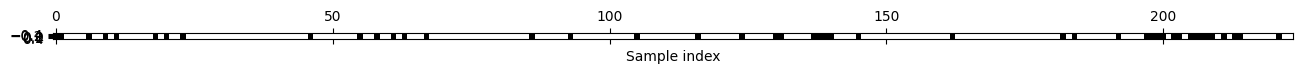

In [ ]:
mask = select.get_support()
# visualize the mask -- black is True, white is False
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")

Try to model it with different algorithms

In [59]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


# 2. Définir les modèles et leurs grilles d'hyperparamètres pour le tuning
models = {
    "Logistic Regression": {
        "model": Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=1000))]),
        "params": {
            "lr__C": np.logspace(-3, 3, 7),
            "lr__class_weight": [None, "balanced"]
        }
    },
    "SVM": {
        "model": Pipeline([("scaler", StandardScaler()), ("svm", SVC(probability=True))]),
        "params": {
            "svm__C": np.logspace(-3, 3, 7),
            "svm__gamma": ["scale", "auto"] + list(np.logspace(-3, 3, 5)),
            "svm__class_weight": [None, "balanced"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "class_weight": [None, "balanced"]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=42),
        "params": {
            "n_estimators": [25, 50, 100, 200],
            "max_depth": [2, 3, 6, 9],
            "learning_rate": [0.001, 0.01, 0.1, 0.2],
            "scale_pos_weight": [1, np.sum(y_train == 0) / np.sum(y_train == 1)]  # Gère le déséquilibre
        }
    }
}

# 3. Entraînement, tuning et évaluation
results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, config in models.items():
    print(f"\n=== Optimisation de {name} ===")
    
    # RandomizedSearchCV pour le fine-tuning
    search = RandomizedSearchCV(
        config["model"], 
        config["params"], 
        n_iter=10,  # Nombre d'itérations (augmentez pour plus de précision)
        cv=kf, 
        scoring="roc_auc_ovr", 
        n_jobs=-1, 
        random_state=42
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    
    # Prédictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    # Métriques
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_auc = roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
    
    # Stockage des résultats
    results.append({
        "Model": name,
        "Best Params": search.best_params_,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Train AUC": train_auc,
        "Test AUC": test_auc,
        "Overfitting (Accuracy Gap)": train_accuracy - test_accuracy
    })

# 4. Affichage des résultats
results_df = pd.DataFrame(results)
print("\n=== Résultats Finaux ===")
results_df


=== Optimisation de Logistic Regression ===

=== Optimisation de SVM ===

=== Optimisation de Random Forest ===

=== Optimisation de XGBoost ===

=== Résultats Finaux ===


,Model,Best Params,Train Accuracy,Test Accuracy,Train F1,Test F1,Train AUC,Test AUC,Overfitting (Accuracy Gap)
0,Logistic Regression,"{'lr__class_weight': 'balanced', 'lr__C': 0.001}",0.625945,0.603015,0.701508,0.697318,0.698899,0.683500,0.022930
1,SVM,"{'svm__gamma': 'scale', 'svm__class_weight': N...",0.772040,0.804020,0.864216,0.888252,0.902536,0.563846,-0.031980
2,Random Forest,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.986146,0.738693,0.990493,0.841463,0.998785,0.627995,0.247453
3,XGBoost,"{'scale_pos_weight': 0.3595890410958904, 'n_es...",0.788413,0.628141,0.839080,0.733813,0.899022,0.631180,0.160272


# Full automated pipeline 

In [5]:
from sklearn.feature_selection import SelectPercentile
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Pipeline compatible avec SMOTE


In [ ]:
import numpy as np
import pandas as pd
from time import time
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import joblib

In [ ]:
# 1. Configuration Optimisée --------------------------------------------------
config = {
    'test_size': 0.2,                  # Une seule valeur représentative
    'percentiles': [30, 50],           # Réduit de 7 à 2 valeurs
    'pca_variances': [0.95],           # Une seule valeur si PCA
    'n_folds': 3,                      # Réduit de 5 à 3 folds
    'n_iter': 30,                      # Itérations pour BayesSearchCV
    'features_sets': {
        'Without Context': filtered_list, 
        'With Context': features
    }
}

# 2. Préparation des Données --------------------------------------------------
# Création de la target
i = 1
df['med_tresh'] = (df[f'WS/48-{i}_target'] > 0).astype(int)
X_raw = df[features]
y = df['med_tresh']


# 3. Pipeline Unifié avec Feature Selection Intelligente -----------------------
base_pipeline = ImbPipeline([
    ('feature_selector', SelectFromModel(
        LogisticRegression(penalty='l1', solver='saga', class_weight='balanced', max_iter=1000)
    )),
    ('scaler', RobustScaler()),
    ('resampler', 'passthrough'),
    ('pca', PCA()),
    ('classifier', None)
])

# 4. Définition des Modèles et Espaces de Recherche ---------------------------
models_config = {
    "Logistic Regression": {
        "classifier": LogisticRegression(max_iter=2000, class_weight='balanced', solver='saga', penalty='elasticnet', l1_ratio=0.5),
        "params": {
            'feature_selector__max_features': Integer(1, X.shape[1]),
            'pca__n_components': Categorical([None, config['pca_variances'][0]]),  # PCA désactivé
            'classifier__C': Real(1e-2, 1e2, 'log-uniform'),
            'resampler': Categorical(['passthrough', SMOTETomek(random_state=42)])
        }
    },
    "SVM": {
        "classifier": SVC(probability=True, class_weight='balanced'),
        "params": {
            'feature_selector__max_features': Integer(1, X.shape[1]),
            'classifier__kernel': Categorical(['rbf', 'poly']),
            'pca__n_components': Categorical([None, config['pca_variances'][0]]),
            'classifier__C': Real(1e-1, 1e3, 'log-uniform'),
            'classifier__gamma': Real(1e-4, 1e1, 'log-uniform'),
            'resampler': Categorical(['passthrough', SMOTETomek(random_state=42)])
        }
    },
    "Random Forest": {
        "classifier": RandomForestClassifier(class_weight='balanced_subsample'),
        "params": {
            'feature_selector__max_features': Categorical([None]),  # La sélection de features est déjà faite
            'pca__n_components': Categorical([None, config['pca_variances'][0]]),
            'classifier__n_estimators': Integer(25, 150),
            'classifier__max_depth': Integer(2, 8),
            'classifier__min_samples_split': Integer(5, 10),
            'resampler': Categorical(['passthrough', SMOTETomek(random_state=42)])
        }
    },
    "XGBoost": {
        "classifier": XGBClassifier(
            scale_pos_weight=np.sum(y == 1)/np.sum(y == 0),
            eval_metric='auc',
            early_stopping_rounds=20),  # Ratio ~3.55
        "params": {
            'feature_selector__max_features': Integer(1, X.shape[1]),
            'pca__n_components': Categorical([None, config['pca_variances'][0]]),
            'classifier__learning_rate': Real(0.05, 0.3, 'log-uniform'),
            'classifier__max_depth': Integer(2, 7),
            'classifier__subsample': Real(0.6, 1.0, 'uniform'),
            'resampler': Categorical(['passthrough', SMOTETomek(random_state=42)])
        }
    }
}

# 5. Fonction d'Entraînement Optimisée ----------------------------------------
def optimized_training(X_train, X_test, y_train, y_test):
    results = []
    
    for model_name, config in models_config.items():
        pipeline = base_pipeline.set_params(classifier=config['classifier'])
        
        search = BayesSearchCV(
            estimator=pipeline,
            search_spaces=config['params'],
            n_iter=config.get('n_iter', 30),
            cv=StratifiedKFold(config.get('n_folds', 3)),
            scoring='roc_auc_ovr',
            n_jobs=-1,
            verbose=1
        )
        
        start_time = time()
        search.fit(X_train, y_train)
        training_time = (time() - start_time)/60  # en minutes
        
        # Prédictions
        train_pred = search.best_estimator_.predict(X_train)
        test_pred = search.best_estimator_.predict(X_test)
        train_proba = search.best_estimator_.predict_proba(X_train)[:, 1]
        test_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
        best_params = search.best_params_
        
        # Stockage des résultats
        results.append({
            'Features Set': features_set_name,
            'Model': model_name,
            'Train Accuracy': accuracy_score(y_train, train_pred),
            'Test Accuracy': accuracy_score(y_test, test_pred),
            'F1': f1_score(y_test, test_pred),
            'Best AUC': roc_auc_score(y_test, test_proba),
            'Training Time (min)': round(training_time, 1),
            'Best Params': best_params
        })
    
    return pd.DataFrame(results)

# 6. Exécution sur les Deux Ensembles de Features -----------------------------
final_results = []

for features_set_name, context in config['features_sets'].items():
    X = X_raw[context]
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=config['test_size'],
    stratify=y,
    random_state=42
    )
    df_results = optimized_training(X_train, X_test, y_train, y_test)
    final_results.append(df_results)

# 7. Consolidation et Sauvegarde des Résultats ---------------------------------
final_df = pd.concat(final_results)
#final_df.to_csv(f'optimized_results_{int(time())}.csv', index=False)
print("Entraînement terminé ! Résultats sauvegardés.")
final_df

In [ ]:
import numpy as np
import pandas as pd
from time import time
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from skopt import BayesSearchCV
from imblearn.under_sampling import RandomUnderSampler
from skopt.space import Real, Categorical, Integer
import joblib

# 1. Configuration Optimisée --------------------------------------------------
config = {
    'test_size': 0.2,                  # Une seule valeur représentative
    'percentiles': [30, 50],           # Réduit de 7 à 2 valeurs
    'pca_variances': [0.95],           # Une seule valeur si PCA
    'n_folds': 3,                      # Réduit de 5 à 3 folds
    'n_iter': 30,                      # Itérations pour BayesSearchCV
    'features_sets': {
        'Without Context': filtered_list, 
        'With Context': features
    }
}

# 2. Préparation des Données --------------------------------------------------
# Création de la target
i = 1
df['med_tresh'] = (df[f'WS/48-{i}_target'] > 0).astype(int)
X_raw = df[features]
y = df['med_tresh']


# 3. Pipeline Unifié avec Feature Selection Intelligente -----------------------
base_pipeline = ImbPipeline([
    ('feature_selector', SelectFromModel(
        LogisticRegression(penalty='l1', solver='saga', 
                           class_weight='balanced', max_iter=1000)
    )),
    ('scaler', RobustScaler()),
    ('resampler', 'passthrough'),
    ('pca', PCA()),
    ('classifier', None)
])

# 4. Définition des Modèles et Espaces de Recherche ---------------------------
models_config = {
    "Logistic Regression": {
        "classifier": LogisticRegression(max_iter=2000, class_weight='balanced', 
                                         solver='saga', penalty='elasticnet'),
        "params": {
            'feature_selector__max_features': Integer(20, X.shape[1]),
            'pca__n_components': Categorical([None, config['pca_variances'][0], 0.99]),  # PCA désactivé
            'classifier__C': Real(1e-3, 1e2, 'log-uniform'),
            'classifier__l1_ratio': Real(0, 1, 'uniform'),
            'resampler': Categorical(['passthrough', SMOTETomek(random_state=42),
                                      RandomUnderSampler(random_state=42)])
        }
    },
    "SVM": {
        "classifier": SVC(probability=True, class_weight='balanced'),
        "params": {
            'feature_selector__max_features': Integer(10, X.shape[1]),
            'classifier__kernel': Categorical(['rbf', 'poly', 'linear']),
            'pca__n_components': Categorical([None, config['pca_variances'][0], 0.99]),
            'classifier__C': Real(1e-2, 1e3, 'log-uniform'),
            'classifier__gamma': Real(1e-5, 1e1, 'log-uniform'),
            'resampler': Categorical(['passthrough', SMOTETomek(random_state=42),
                                      RandomUnderSampler(random_state=42)])
        }
    },
    "Random Forest": {
        "classifier": RandomForestClassifier(class_weight='balanced_subsample'),
        "params": {
            'feature_selector__max_features': Integer(10, X.shape[1]),  # La sélection de features est déjà faite
            'pca__n_components': Categorical([None, config['pca_variances'][0], 0.99]),
            'classifier__n_estimators': Integer(50, 200),
            'classifier__max_depth': Integer(3, 10),
            'classifier__min_samples_split': Integer(10, 50),
            'classifier__min_samples_leaf': Integer(5, 20),
            'resampler': Categorical(['passthrough', SMOTETomek(random_state=42),
                                      RandomUnderSampler(random_state=42)])
        }
    },
    "XGBoost": {
        "classifier": XGBClassifier(
            scale_pos_weight=np.sum(y == 1)/np.sum(y == 0),
            eval_metric='auc'),  # Ratio ~3.55
        "params": {
            'feature_selector__max_features': Integer(10, X.shape[1]),
            'pca__n_components': Categorical([None, config['pca_variances'][0], 0.99]),
            #'classifier__n_estimators': Integer(50, 500),
            'classifier__learning_rate': Real(0.01, 0.3, 'log-uniform'),
            #'classifier__colsample_bytree': Real(0.5, 1.0, 'uniform'),
            #'classifier__min_child_weight': Integer(1, 10),
            'classifier__max_depth': Integer(2, 6),
            'classifier__subsample': Real(0.5, 1.0, 'uniform'),
            'classifier__colsample_bytree': Real(0.5, 1.0, 'uniform'),
            'classifier__gamma': Real(0, 5),
            'resampler': Categorical(['passthrough', SMOTETomek(random_state=42),
                                      RandomUnderSampler(random_state=42)])
        }
    }
}

# 5. Fonction d'Entraînement Optimisée ----------------------------------------
def optimized_training(X_train, X_test, y_train, y_test):
    results = []
    
    for model_name, config in models_config.items():
        pipeline = base_pipeline.set_params(classifier=config['classifier'])
        
        search = BayesSearchCV(
            estimator=pipeline,
            search_spaces=config['params'],
            n_iter=config.get('n_iter', 30),
            cv=StratifiedKFold(config.get('n_folds', 3)),
            scoring='roc_auc_ovr',
            n_jobs=-1,
            verbose=1,
            random_state=42
        )
        
        start_time = time()
        search.fit(X_train, y_train)
        training_time = (time() - start_time)/60  # en minutes
        
        # Prédictions
        train_pred = search.best_estimator_.predict(X_train)
        test_pred = search.best_estimator_.predict(X_test)
        train_proba = search.best_estimator_.predict_proba(X_train)[:, 1]
        test_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
        best_params = search.best_params_
        
        # Stockage des résultats
        results.append({
            'Features Set': features_set_name,
            'Model': model_name,
            'Train Accuracy': accuracy_score(y_train, train_pred),
            'Test Accuracy': accuracy_score(y_test, test_pred),
            'F1': f1_score(y_test, test_pred),
            'Best AUC': roc_auc_score(y_test, test_proba),
            'Training Time (min)': round(training_time, 1),
            'Best Params': best_params
        })
    
    return pd.DataFrame(results)

# 6. Exécution sur les Deux Ensembles de Features -----------------------------
final_results = []

for features_set_name, context in config['features_sets'].items():
    X = X_raw[context]
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=config['test_size'],
    stratify=y,
    random_state=42
    )
    df_results = optimized_training(X_train, X_test, y_train, y_test)
    final_results.append(df_results)

# 7. Consolidation et Sauvegarde des Résultats ---------------------------------
final_df = pd.concat(final_results)
#final_df.to_csv(f'optimized_results_{int(time())}.csv', index=False)
print("Entraînement terminé ! Résultats sauvegardés.")
final_df

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    df[context], y, 
    test_size=config['test_size'],
    stratify=y,
    random_state=42
    )

## Features selection methods comparison

In [16]:
#Configuration of the comparison - we use the full features dataset

##NBA-inspired styling
nba_palette = ['#1D428A', '#C8102E', '#FDB927', '#000000', '#007A33']
court_color = '#F5F5F5'
##Create a database that stores the values of AUC, F1, Accuracy (Test & Train) for the three logistic regression models to be able to compare them 
models = {
    'logistic' : LogisticRegression(max_iter=1000, random_state=42),
    'xgb' : XGBClassifier(use_label_encoder=False, eval_metric='auc', 
                          random_state=42),
    'svc' : SVC(probability=True, kernel='rbf', random_state=42)
}
#clf = LogisticRegression(max_iter=1000, random_state=42)

##Create the variables
X_f_s = df[df['flag_reports_features'] == 1][features]
scaler = StandardScaler()
X_f_s = scaler.fit_transform(X_f_s)
i = 1
df['med_tresh'] = (df[f'WS/48-{i}_target'] > 0).astype(int)
y_f_s = df[df['flag_reports_features'] == 1]['med_tresh']

auc = []
f1 = []
test_acc = []
train_acc = []
name = []

### PCA

In [ ]:
# Étape 3 : entraînement
var_thresholds = [0.9, 0.95, 0.99] #We test 3 thresholds 



for i in var_thresholds:
    pca = PCA(n_components=i, random_state=42)
    X_pca = pca.fit_transform(X_f_s)
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y_f_s, test_size=0.2, 
                                                        random_state=42, stratify=y_f_s)
    for model_name, model in models.items():
        clf = model 
        clf.fit(X_train, y_train)
        y_train_pred = clf.predict(X_train)
        y_test_pred = clf.predict(X_test)
        y_test_prob = clf.predict_proba(X_test)[:, 1]
        # Étape 5 : métriques
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))
        auc.append(roc_auc_score(y_test, y_test_prob))
        f1.append(f1_score(y_test, y_test_pred))
        name.append(f'pca_{i}_threshold_{model_name}')


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:48:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:48:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:48:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### Visualisation

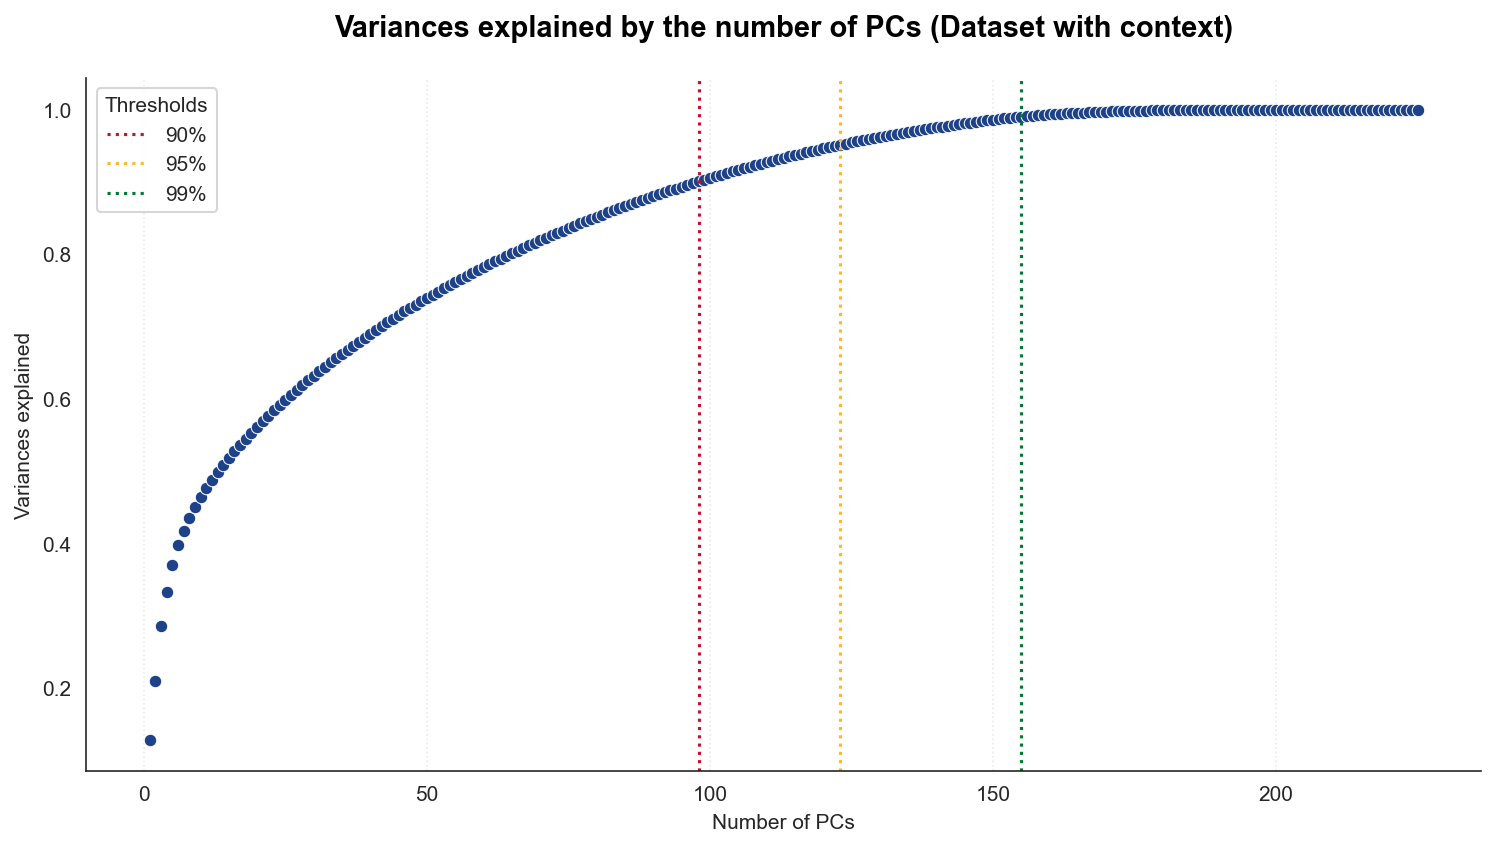

In [ ]:
# 4. Calcul de la variance expliquée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
# 5. Affichage du graphique
plt.figure(figsize=(12, 6), dpi=150)
sns.set_style('white')
sns.scatterplot(x=range(1, len(cumulative_variance) + 1), y=cumulative_variance, color=nba_palette[0])
plt.title("Variances explained by the number of PCs (Dataset with context)",
          fontsize=14, fontweight='bold', pad=20, color='black')
plt.xlabel("Number of PCs")
plt.ylabel("Variances explained")
plt.grid(axis='x', linestyle=':', alpha=0.4)
plt.axvline(x=np.argmax(cumulative_variance >= 0.9
                        ) + 1, color=nba_palette[1], linestyle=':', label='90%')
plt.axvline(x=np.argmax(cumulative_variance >= 0.95
                        ) + 1, color=nba_palette[2], linestyle=':', label='95%')
plt.axvline(x=np.argmax(cumulative_variance >= 0.99
                        ) + 1, color=nba_palette[4], linestyle=':', label='99%')
plt.legend(title='Thresholds')
sns.despine()
plt.show()


### ANOVA

In [18]:
# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X_f_s, y_f_s, test_size=0.2, 
                                                    random_state=42, stratify=y_f_s)

from sklearn.feature_selection import SelectPercentile
percentile_thresholds = [0.05, 0.25,  
                         0.5, 1]
for model_name, model in models.items():
    clf = model
    for i in percentile_thresholds:
        select = SelectPercentile(percentile=i)
        select.fit(X_train, y_train)
        # transform training set
        X_train_selected = select.transform(X_train)
        # transform test data
        X_test_selected = select.transform(X_test)

        clf.fit(X_train_selected, y_train)
        y_train_pred = clf.predict(X_train_selected)
        y_test_pred = clf.predict(X_test_selected)
        y_test_prob = clf.predict_proba(X_test_selected)[:, 1]
        # Étape 5 : métriques
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))
        auc.append(roc_auc_score(y_test, y_test_prob))
        f1.append(f1_score(y_test, y_test_pred))
        name.append(f'anova_{i}_threshold_{model_name}')

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [  4   5  10  19  96 124] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [  4   5  10  19  96 124] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\Utilisateur\AppData\Local\P

#### Visualization

In [ ]:
mask = select.get_support()
# visualize the mask -- black is True, white is False
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")

### XGB SelectFromModel

In [20]:
# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X_f_s, y_f_s, test_size=0.2, 
                                                    random_state=42, stratify=y_f_s)

#Choose estimators
estimators = {
    'logistic' : LogisticRegression(max_iter=1000, random_state=42),
    'xgb' : XGBClassifier(use_label_encoder=False, 
                          eval_metric='auc', random_state=42),
    'randomforest' : RandomForestClassifier(random_state=42)
}
# Pipeline de sélection + modèle
for model_name, model in models.items():
    clf = model
    for estimator_name, estimator in estimators.items():
        pipeline = Pipeline([
            ('feature_selection', SelectFromModel(estimator=estimator)),
            ('classifier', clf)
        ])

        # Grille de recherche
        param_dist = {
            'feature_selection__max_features': Integer(10, 90),  # Seuils basés sur l'importance
        }

        # Randomized Search
        search = BayesSearchCV(
            pipeline,
            search_spaces=param_dist,
            n_iter=100,
            cv=StratifiedKFold(3),
            scoring='roc_auc',
            random_state=42,
            verbose=1,
            n_jobs=-1
        )

        # Entraînement
        search.fit(X_train, y_train)

        # Prédictions
        y_pred = search.predict(X_test)
        y_proba = search.predict_proba(X_test)[:, 1]
        y_train_pred = search.predict(X_train)

        # Résultats
        print("Best threshold selected:", search.best_params_['feature_selection__max_features'])
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_pred))
        auc.append(roc_auc_score(y_test, y_proba))
        f1.append(f1_score(y_test, y_pred))
        name.append(f'{estimator_name}_{model_name}')


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(79)] before, using random point [np.int64(80)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(77)] before, using random point [np.int64(30)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


...

Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(21)] before, using random point [np.int64(38)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(71)] before, using random point [np.int64(34)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best threshold selected: 71


In [277]:
# 1. Sélection des features avec le pipeline entraîné
feature_selector = search.best_estimator_.named_steps['feature_selection']
X_train_sel = feature_selector.transform(X_train)
X_test_sel = feature_selector.transform(X_test)
# 2. Définir les deux modèles
models = {
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42),
    'SVM': SVC(probability=True, kernel='rbf', random_state=42)
}

# 3. Boucle d'évaluation
for model_name, model in models.items():
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    y_proba = model.predict_proba(X_test_sel)[:, 1]

    print(f"\n🔹 {model_name} Results:")
    print(f"Train Accuracy: {model.score(X_train_sel, y_train)*100:.2f}%")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(f"F1 Score: {f1_score(y_test, y_pred)*100:.2f}%")
    print(f"AUC Score: {roc_auc_score(y_test, y_proba)*100:.2f}%")


🔹 XGBoost Results:
Train Accuracy: 100.00%
Test Accuracy: 72.58%
F1 Score: 83.17%
AUC Score: 61.02%

🔹 SVM Results:
Train Accuracy: 80.65%
Test Accuracy: 79.03%
F1 Score: 87.96%
AUC Score: 58.40%


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:47:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Results

In [21]:
comparison_f_s = {
    'Feature Selection method': name,
    'Train Accuracy' : train_acc,
    'Test Accuracy' : test_acc,
    'F1' : f1,
    'AUC': auc
}

pd.DataFrame(comparison_f_s)

,Feature Selection method,Train Accuracy,Test Accuracy,F1,AUC
0,pca_0.9_threshold_logistic,0.852823,0.677419,0.793814,0.584029
1,pca_0.9_threshold_xgb,1.000000,0.758065,0.858491,0.508893
2,pca_0.9_threshold_svc,0.856855,0.766129,0.867580,0.607985
3,pca_0.95_threshold_logistic,0.862903,0.685484,0.797927,0.607623
4,pca_0.95_threshold_xgb,1.000000,0.741935,0.850467,0.512523
5,pca_0.95_threshold_svc,0.879032,0.766129,0.867580,0.588385
6,pca_0.99_threshold_logistic,0.885081,0.693548,0.808081,0.615245
7,pca_0.99_threshold_xgb,1.000000,0.766129,0.865116,0.515064
8,pca_0.99_threshold_svc,0.879032,0.766129,0.867580,0.596733
9,anova_0.05_threshold_logistic,0.768145,0.766129,0.867580,0.659891


## Testing

StratfiedKFolds pour garder la proportion des classes
ImbPipeline pour éviter le data leakage dans la pipeline (exemple SMOTE)
SMOTE pour suréchantillonage de classe minoritarie
Tomek pour supprimer les liens ambigus entre les classes
Différents score de F1 car utilisation de F1 Macro, prends la moyenne des F1 individuel de chaque classe
[df['flag_reports_features']==1]

Pipeline:
1. y Creation 
2. X creation (With and Without context)
3. splitting the dataset
4. SMOTETomek
5. Scaling (Standard)
6. Selection (RF and LR)
7. With the features selected making models run (XGB, RF, LR, SVC)
8. Evaluation of the results (F1, AUC, Acc)
9. Test of hypothesis (DeLong and McNemar)
10. Look at the prediction (the best model in monetary terms)

### Complete Pipeline

The first one is with Logisitc Regression 

The Second one is with Random Forest

In [112]:
def select_features(X_train, X_test, y_train, 
                    selector='randomforest', max_features_range=(1, 50), 
                    n_iter=10):
    """
    Sélectionne un sous-ensemble optimal de caractéristiques avec SelectFromModel en optimisant max_features.
    
    Parameters:
    -----------
    X_train : pd.DataFrame
        Données d'entraînement.
    X_test : pd.DataFrame
        Données de test.
    y_train : np.array
        Cibles d'entraînement.
    selector : str
        Nom du sélecteur (par exemple, 'randomforest').
    max_features_range : tuple
        Plage pour max_features (par exemple, (1, X.shape[1])).
    n_iter : int
        Nombre d'itérations pour BayesSearchCV.
        
    Returns:
    --------
    X_train_selected : np.array
        Données d'entraînement avec caractéristiques sélectionnées.
    X_test_selected : np.array
        Données de test avec caractéristiques sélectionnées.
    selected_features : list
        Liste des noms des caractéristiques sélectionnées.
    best_max_features : int
        Valeur optimale de max_features.
    """
    print(f"Optimisation de max_features avec {selector}...")
    
    # Pipeline pour la sélection
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('resampler', SMOTETomek(random_state=42, sampling_strategy=0.5)),
        ('selector', SelectFromModel(
            estimator=RandomForestClassifier(random_state=42, class_weight='balanced')
        )),
        ('classifier', XGBClassifier(random_state=42))  # Classifieur de référence
    ])
    
    # Espace de recherche pour max_features
    search_spaces = {
        'selector__max_features': Integer(max_features_range[0], min(max_features_range[1], X_train.shape[1]))
    }
    
    # Optimisation avec BayesSearchCV
    search = BayesSearchCV(
        estimator=pipeline,
        search_spaces=search_spaces,
        n_iter=n_iter,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    best_max_features = search.best_params_['selector__max_features']
    
    # Ajustement final avec max_features optimal
    feature_selector = ImbPipeline([
        ('scaler', StandardScaler()),
        ('resampler', SMOTETomek(random_state=42, sampling_strategy=0.5)),
        ('selector', SelectFromModel(
            estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
            max_features=best_max_features
        ))
    ])
    
    feature_selector.fit(X_train, y_train)
    X_train_selected = feature_selector.transform(X_train)
    X_test_selected = feature_selector.transform(X_test)
    
    # Récupération des caractéristiques sélectionnées
    selected_mask = feature_selector.named_steps['selector'].get_support()
    selected_features = X_train.columns[selected_mask].tolist()
    
    print(f"max_features optimal: {best_max_features}")
    print(f"Nombre de caractéristiques sélectionnées: {len(selected_features)}")
    print(f"Caractéristiques sélectionnées: {selected_features}")
    

    
    return X_train_selected, X_test_selected, selected_features, best_max_features

In [108]:
def optimized_training(X_train, X_test, 
                       y_train, y_test,
                       classifiers, config,
                       selector, search_spaces
                    ):
    
    results = []
    for model_name in classifiers:
        pipeline = base_pipeline.set_params(classifier=classifiers[model_name])

        search = BayesSearchCV(
            estimator=pipeline,
            search_spaces=search_spaces[model_name],
            n_iter=config['n_iter'],
            cv=StratifiedKFold(config['n_folds']),
            scoring=config['scoring'],
            n_jobs=-1,
            verbose=1,
            random_state=42
        )

        start_time = time()
        search.fit(X_train, y_train)
        joblib.dump(search.best_estimator_, f"best_model_{features_set_name}_{model_name.replace(' ', '_')}_{selector}.pkl")
        training_time = (time() - start_time)/60  # en minutes
        
        # Prédictions
        train_pred = search.best_estimator_.predict(X_train)
        test_pred = search.best_estimator_.predict(X_test)
        train_proba = search.best_estimator_.predict_proba(X_train)[:, 1]
        test_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
        best_params = search.best_params_

        # Stockage des résultats
        results.append({
            'Features Set': features_set_name,
            'Model': model_name,
            'Train Accuracy': accuracy_score(y_train, train_pred),
            'Test Accuracy': accuracy_score(y_test, test_pred),
            'F1': f1_score(y_test, test_pred),
            'Best AUC': roc_auc_score(y_test, test_proba),
            'Training Time (min)': round(training_time, 1),
            'Best Params': best_params,
        })
    
    return pd.DataFrame(results)

In [128]:
#0. Pipeline configuration
config = {
    'test_size': 0.2,
    'n_folds': 3,
    'n_iter' : 10, 
    'scoring': 'roc_auc',
    'features_max': 50,
    'features_sets' : {
        'Without' : filtered_list,
        'With': features
    }
}

#1 y creation 
i = 1
df['med_tresh'] = (df[f'WS/48-{i}_target'] > 0).astype(int)
y = df['med_tresh']

#2 X Creation
X_raw = df[features] #Full dataset with every features


## Base pipeline
base_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('resampler', SMOTETomek(sampling_strategy=0.5)),
    ('classifier', None)
])

#3. Classification model definition
classifiers = {
    'xgboost': XGBClassifier(random_state=42, 
                             eval_metric='auc'),
    'logistic_regression': LogisticRegression(random_state=42, 
                                              penalty='elasticnet',
                                              solver='saga'),
    'random_forest': RandomForestClassifier(random_state=42, 
                                            max_samples=0.7),
    'svm': SVC(random_state=42, 
               probability=True)
}

#4. Parameters search space
search_spaces = {
    'xgboost': {
        #'classifier__learning_rate': Real(0.01, 0.2, prior='log-uniform'),
        'classifier__max_depth': Integer(2, 7),
        #'classifier__n_estimators': Integer(100, 500),
        #'classifier__subsample': Real(0.6, 1.0, 'uniform'),
        #'classifier__colsample_bytree': Real(0.6, 1.0, 'uniform'),
        #'classifier__gamma': Real(0, 1),
        #'feature_selection__max_features': Integer(1, X.shape[1]),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'logistic_regression': {
        #'classifier__C': Real(0.01, 10.0, prior='log-uniform'),
        #'feature_selection__max_features': Integer(1, X.shape[1]),
        'classifier__l1_ratio': Real(0.3, 0.7, 'uniform'),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'random_forest': {
        #'classifier__n_estimators': Integer(100, 500),
        'classifier__max_depth': Integer(2, 6),
        #'classifier__min_samples_split': Integer(5, 20),
        #'classifier__max_features': Categorical(['sqrt', 0.5]),
        #'feature_selection__max_features': Integer(1, X.shape[1]),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'svm': {
        'classifier__C': Real(0.5, 50.0, prior='log-uniform'),
        #'classifier__gamma': Categorical(['scale', 'auto'] + list(np.logspace(-3, -1, 5))),
        #'classifier__kernel': Categorical(['rbf', 'linear']),
        #'feature_selection__max_features': Integer(1, X.shape[1]), 
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    }
}

final_results = []
for features_set_name, context in config['features_sets'].items():
    X = X_raw[context]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=config['test_size'],
        stratify=y,
        random_state=42
    )
    X_train_selected, X_test_selected, features_selected, best_max_features = select_features(
        X_train, X_test, y_train,
        max_features_range=(25, 50),
        n_iter=config['n_iter'])

    df_results = optimized_training(
        X_train_selected, X_test_selected, 
        y_train, y_test,
        classifiers, config, 
        'randomforest', search_spaces
    )

    final_results.append(df_results)

final_df = pd.concat(final_results)
final_df

Optimisation de max_features avec randomforest...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
max_features optimal: 45
Nombre de caractéristiques sélectionnées: 45
Caractéristiques sélectionnées: ['Weight_features', 'per_40_FG_features', 'per_40_FGA_features', 'per_40_FG%_features', 'per_40_3P_features', 'per_40_3PA_features', 'per_40_3P%_features', 'per_40_2PA_features', 'per_40_2P%_features', 'per_40_eFG%_features', 'per_40_FT_features', 'per_40_FT

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

,Features Set,Model,Train Accuracy,Test Accuracy,F1,Best AUC,Training Time (min),Best Params
0,Without,xgboost,0.976680,0.721311,0.823529,0.697068,0.0,"{'classifier__max_depth': 7, 'resampler__sampl..."
1,Without,logistic_regression,0.724280,0.699454,0.792453,0.712809,0.0,"{'classifier__l1_ratio': 0.5936112071942273, '..."
2,Without,random_forest,0.813443,0.770492,0.857143,0.794599,0.0,"{'classifier__max_depth': 4, 'resampler__sampl..."
3,Without,svm,0.772291,0.759563,0.848276,0.782099,0.0,"{'classifier__C': 0.5084293568002323, 'resampl..."
0,With,xgboost,0.987654,0.754098,0.845361,0.693981,0.0,"{'classifier__max_depth': 6, 'resampler__sampl..."
1,With,logistic_regression,0.744856,0.754098,0.843206,0.756019,0.0,"{'classifier__l1_ratio': 0.6249583953429454, '..."
2,With,random_forest,0.835391,0.748634,0.847682,0.779167,0.1,"{'classifier__max_depth': 5, 'resampler__sampl..."
3,With,svm,0.779150,0.754098,0.842105,0.786883,0.1,"{'classifier__C': 0.5084293568002323, 'resampl..."


In [69]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# 2. Préparation des Données --------------------------------------------------
# Création de la target
i = 1
df['med_tresh'] = (df[f'WS/48-{i}_target'] > 0).astype(int)
X_raw = df[features]
y = df['med_tresh']
current_max_features = X_raw.shape[1]

# Étape 2 : Définition des modèles de classification
classifiers = {
    'xgboost': XGBClassifier(random_state=42, 
                             eval_metric='auc'),
    'logistic_regression': LogisticRegression(random_state=42, penalty='elasticnet',
                                              solver='saga'),
    'random_forest': RandomForestClassifier(random_state=42, 
                                            max_samples=0.7),
    'svm': SVC(random_state=42, 
               probability=True)
}

# Étape 3 : Définition des espaces de recherche pour les hyperparamètres
search_spaces = {
    'xgboost': {
        'classifier__learning_rate': Real(0.01, 0.2, prior='log-uniform'),
        'classifier__max_depth': Integer(2, 7),
        'classifier__n_estimators': Integer(100, 500),
        'classifier__subsample': Real(0.6, 1.0, 'uniform'),
        'classifier__colsample_bytree': Real(0.6, 1.0, 'uniform'),
        'classifier__gamma': Real(0, 1),
        'feature_selection__max_features': Integer(1, X.shape[1]),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'logistic_regression': {
        'classifier__C': Real(0.01, 10.0, prior='log-uniform'),
        'feature_selection__max_features': Integer(1, X.shape[1]),
        'classifier__l1_ratio': Real(0.3, 0.7, 'uniform'),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'random_forest': {
        'classifier__n_estimators': Integer(100, 500),
        'classifier__max_depth': Integer(2, 6),
        'classifier__min_samples_split': Integer(5, 20),
        'classifier__max_features': Categorical(['sqrt', 0.5]),
        'feature_selection__max_features': Integer(1, X.shape[1]),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'svm': {
        'classifier__C': Real(0.5, 50.0, prior='log-uniform'),
        'classifier__gamma': Categorical(['scale', 'auto'] + list(np.logspace(-3, -1, 5))),
        'classifier__kernel': Categorical(['rbf', 'linear']),
        'feature_selection__max_features': Integer(1, X.shape[1]), 
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    }
}

# Étape 4 : Boucle sur chaque classifieur pour créer et optimiser la pipeline
# Étape 2 : Split en train/test
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, 
                                                    random_state=42)

results = {}
for clf_name, clf in classifiers.items():
    print(f"\nOptimisation pour {clf_name}...")
    
    # Création de la pipeline
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('feature_selection', SelectFromModel(XGBClassifier(random_state=42, 
                                                            scale_pos_weight=np.bincount(y_train)[0]/np.bincount(y_train)[1]))),
        ('resampler', SMOTETomek(random_state=42)),
        ('classifier', clf)
    ])
    
    # Configuration de BayesSearchCV
    bayes_search = BayesSearchCV(
        estimator=pipeline,
        search_spaces=search_spaces[clf_name],
        n_iter=10,  # Nombre d'itérations pour l'optimisation
        cv=StratifiedKFold(3),       # Validation croisée à 5 plis
        scoring='roc_auc',
        n_jobs=-1,  # Utiliser tous les cœurs disponibles
        random_state=42,
        verbose=1
    )
    
    # Ajustement de la pipeline
    bayes_search.fit(X_train, y_train)
    
    # Étape 5 : Calcul des métriques avec le meilleur modèle
    best_model = bayes_search.best_estimator_
    y_pred = best_model.predict(X_test)  # Prédictions pour accuracy et F1
    y_proba = best_model.predict_proba(X_test)[:, 1]  # Probabilités pour AUC
    
    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)  
    auc = roc_auc_score(y_test, y_proba)
    
    # Stockage des résultats
    results[clf_name] = {
        'best_score_cv': bayes_search.best_score_,
        'best_params': bayes_search.best_params_,
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': auc
    }
    
    # Affichage des résultats
    print(f"Meilleur score CV pour {clf_name}: {bayes_search.best_score_:.4f}")
    print(f"Meilleurs paramètres: {bayes_search.best_params_}")
    print(f"Métriques sur l'ensemble des données:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print(f"  ROC-AUC: {auc:.4f}")

# Étape 6 : Résumé des résultats
print("\nRésumé des résultats:")
for clf_name, result in results.items():
    print(f"{clf_name}:")
    print(f"  Score CV = {result['best_score_cv']:.4f}")
    print(f"  Accuracy = {result['accuracy']:.4f}")
    print(f"  F1-score = {result['f1_score']:.4f}")
    print(f"  ROC-AUC = {result['roc_auc']:.4f}")
    print(f"  Paramètres = {result['best_params']}")


Optimisation pour xgboost...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Meilleur score CV pour xgboost: 0.6317
Meilleurs paramètres: OrderedDict({'classifier__colsample_bytree': 0.7779330049204607, 'classifier__gamma': 0.9187225216693771, 'classifier__learning_rate': 0.013690676564850015, 'classifier__max_depth': 4, 'classifier__n_estimators': 175, 'classifier__subsample': 0.7814661375225196, 'feature_selection__estimator__max_depth': 3, 'feature_s

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Meilleur score CV pour random_forest: 0.6653
Meilleurs paramètres: OrderedDict({'classifier__max_depth': 4, 'classifier__max_features': 0.5, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 450, 'feature_selection__estimator__max_depth': 5, 'feature_selection__max_features': 134, 'resampler__sampling_strategy': 0.6297555019407451})
Métriques sur l'ensemble des données:
  Accuracy: 0.7705
  F1-score : 0.8600
  ROC-AUC: 0.7221

Optimisation pour svm...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fit

In [ ]:
import numpy as np
import pandas as pd
from time import time
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from skopt import BayesSearchCV
from imblearn.under_sampling import RandomUnderSampler
from skopt.space import Real, Categorical, Integer
import joblib
from sklearn.linear_model import ElasticNet

# 1. Configuration Optimisée --------------------------------------------------
config = {
    'test_size': 0.2,                  # Une seule valeur représentative
    'percentiles': [30, 50],           # Réduit de 7 à 2 valeurs
    'pca_variances': [0.95],           # Une seule valeur si PCA
    'n_folds': 3,                      # Réduit de 5 à 3 folds
    'n_iter': 30,                      # Itérations pour BayesSearchCV
    'features_sets': {
        'Without Context': filtered_list, 
        'With Context': features
    }
}

# 2. Préparation des Données --------------------------------------------------
# Création de la target
i = 1
df['med_tresh'] = (df[f'WS/48-{i}_target'] > 0).astype(int)
X_raw = df[df['flag_reports_features'] == 1][features]
y = df[df['flag_reports_features'] == 1]['med_tresh']
current_max_features = X_raw.shape[1]

# 3. Pipeline Unifié avec Feature Selection Intelligente -----------------------
base_pipeline = ImbPipeline([
    ('feature_selector', SelectFromModel(
        ElasticNet(random_state=42, l1_ratio=0.5)
    )),
    ('scaler', StandardScaler()),
    ('resampler', 'passthrough'),
    ('pca', PCA()),
    ('classifier', None)
])

# 4. Définition des Modèles et Espaces de Recherche ---------------------------
models_config = {
    "Logistic Regression": {
        "classifier": LogisticRegression(max_iter=2000, class_weight='balanced', 
                                         solver='saga', penalty='elasticnet'),
        "params": {
            'feature_selector__max_features': Integer(10, X.shape[1]),
            'pca__n_components': Categorical([None]),  # PCA désactivé
            'classifier__C': Real(0.1, 10, 'log-uniform'),
            'classifier__l1_ratio': Real(0.3, 0.7, 'uniform'),
            'resampler': Categorical(['passthrough', 
                                      SMOTETomek(sampling_strategy=0.5, random_state=42)])
        }
    },
    "SVM": {
        "classifier": SVC(probability=True, class_weight='balanced', kernel='rbf'),
        "params": {
            'feature_selector__max_features': Integer(30, X.shape[1]),
            'pca__n_components': Categorical([None]),
            'classifier__C': Real(0.5, 50, 'log-uniform'),
            'classifier__gamma': Categorical(['scale', 'auto'] + list(np.logspace(-3, -1, 5))),
            'resampler': Categorical(['passthrough', 
                                      SMOTETomek(sampling_strategy=0.5, random_state=42)])
        }
    },
    "Random Forest": {
        "classifier": RandomForestClassifier(class_weight='balanced_subsample', max_samples=0.7),
        "params": {
            'feature_selector__max_features': Categorical([None]),  # La sélection de features est déjà faite
            'pca__n_components': Categorical([None]),
            'classifier__n_estimators': Integer(50, X.shape[1]),
            'classifier__max_depth': Integer(2, 6),
            #'classifier__min_samples_split': Integer(5, 20),
            'classifier__min_samples_leaf': Integer(5, 20),
            'classifier__max_features': Categorical(['sqrt', 0.5]),
            'resampler': Categorical(['passthrough', 
                                      SMOTETomek(sampling_strategy=0.5, random_state=42)])
        }
    },
    "XGBoost": {
        "classifier": XGBClassifier(
            scale_pos_weight=np.sum(y == 1)/np.sum(y == 0),
            eval_metric='auc'),  # Ratio ~3.55
        "params": {
            'feature_selector__max_features': Integer(30, X.shape[1]),
            'pca__n_components': Categorical([None]),
            'classifier__learning_rate': Real(0.01, 0.2, 'log-uniform'),
            'classifier__max_depth': Integer(2, 6),
            'classifier__subsample': Real(0.6, 0.9, 'uniform'),
            'classifier__colsample_bytree': Real(0.6, 1.0, 'uniform'),
            'classifier__gamma': Real(0, 1),
            'resampler': Categorical(['passthrough', 
                                      SMOTETomek(sampling_strategy=0.5, random_state=42)])
        }
    }
}

# 5. Fonction d'Entraînement Optimisée ----------------------------------------
def optimized_training(X_train, X_test, y_train, y_test):
    results = []
    
    for model_name, config in models_config.items():
        pipeline = base_pipeline.set_params(classifier=config['classifier'])
        
        search = BayesSearchCV(
            estimator=pipeline,
            search_spaces=config['params'],
            n_iter=config.get('n_iter', 200),
            cv=StratifiedKFold(config.get('n_folds', 5)),
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1,
            random_state=42
        )
        
        start_time = time()
        search.fit(X_train, y_train)
        # Extraction des features sélectionnées
        feature_selector = search.best_estimator_.named_steps['feature_selector']
        selected_mask = feature_selector.get_support()
        selected_features = X_train.columns[selected_mask]
        joblib.dump(search.best_estimator_, f"best_model_{features_set_name}_{model_name.replace(' ', '_')}_condition.pkl")
        training_time = (time() - start_time)/60  # en minutes
        
        # Prédictions
        train_pred = search.best_estimator_.predict(X_train)
        test_pred = search.best_estimator_.predict(X_test)
        train_proba = search.best_estimator_.predict_proba(X_train)[:, 1]
        test_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
        best_params = search.best_params_
        
        # Stockage des résultats
        results.append({
            'Features Set': features_set_name,
            'Model': model_name,
            'Train Accuracy': accuracy_score(y_train, train_pred),
            'Test Accuracy': accuracy_score(y_test, test_pred),
            'F1': f1_score(y_test, test_pred),
            'Best AUC': roc_auc_score(y_test, test_proba),
            'Training Time (min)': round(training_time, 1),
            'Best Params': best_params,
            'Selected Features': list(selected_features),
        })
    
    return pd.DataFrame(results)

# 6. Exécution sur les Deux Ensembles de Features -----------------------------
final_results = []

for features_set_name, context in config['features_sets'].items():
    X = X_raw[context]
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=config['test_size'],
    stratify=y,
    random_state=42
    )
    df_results = optimized_training(X_train, X_test, y_train, y_test)
    final_results.append(df_results)

# 7. Consolidation et Sauvegarde des Résultats ---------------------------------
final_df = pd.concat(final_results)
#final_df.to_csv(f'optimized_results_{int(time())}.csv', index=False)
print("Entraînement terminé ! Résultats sauvegardés.")
final_df

### With the condition

In [37]:
import numpy as np
import pandas as pd
from time import time
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from skopt import BayesSearchCV
from imblearn.under_sampling import RandomUnderSampler
from skopt.space import Real, Categorical, Integer
import joblib

# 1. Configuration Optimisée --------------------------------------------------
config = {
    'test_size': 0.2,                  # Une seule valeur représentative
    'percentiles': [30, 50],           # Réduit de 7 à 2 valeurs
    'pca_variances': [0.95],           # Une seule valeur si PCA
    'n_folds': 3,                      # Réduit de 5 à 3 folds
    'n_iter': 30,                      # Itérations pour BayesSearchCV
    'features_sets': {
        'Without Context': filtered_list, 
        'With Context': features
    }
}

# 2. Préparation des Données --------------------------------------------------
# Création de la target
i = 1
df['med_tresh'] = (df[f'WS/48-{i}_target'] > 0).astype(int)
X_raw = df[df['flag_reports_features'] == 1][features]
y = df[df['flag_reports_features'] == 1]['med_tresh']
current_max_features = X_raw.shape[1]

# 3. Pipeline Unifié avec Feature Selection Intelligente -----------------------
base_pipeline = ImbPipeline([
    ('feature_selector', SelectFromModel(
        LogisticRegression(penalty='elasticnet', solver='saga', 
                           class_weight='balanced', max_iter=1000)
    )),
    ('scaler', StandardScaler()),
    ('resampler', 'passthrough'),
    ('pca', PCA()),
    ('classifier', None)
])

# 4. Définition des Modèles et Espaces de Recherche ---------------------------
models_config = {
    "Logistic Regression": {
        "classifier": LogisticRegression(max_iter=2000, class_weight='balanced', 
                                         solver='saga', penalty='elasticnet'),
        "params": {
            'feature_selector__max_features': Integer(10, X.shape[1]),
            'pca__n_components': Categorical([None]),  # PCA désactivé
            'classifier__C': Real(0.1, 10, 'log-uniform'),
            'classifier__l1_ratio': Real(0.3, 0.7, 'uniform'),
            'resampler': Categorical(['passthrough', 
                                      SMOTETomek(sampling_strategy=0.5, random_state=42)])
        }
    },
    "SVM": {
        "classifier": SVC(probability=True, class_weight='balanced', kernel='rbf'),
        "params": {
            'feature_selector__max_features': Integer(30, X.shape[1]),
            'pca__n_components': Categorical([None]),
            'classifier__C': Real(0.5, 50, 'log-uniform'),
            'classifier__gamma': Categorical(['scale', 'auto'] + list(np.logspace(-3, -1, 5))),
            'resampler': Categorical(['passthrough', 
                                      SMOTETomek(sampling_strategy=0.5, random_state=42)])
        }
    },
    "Random Forest": {
        "classifier": RandomForestClassifier(class_weight='balanced_subsample', max_samples=0.7),
        "params": {
            'feature_selector__max_features': Categorical([None]),  # La sélection de features est déjà faite
            'pca__n_components': Categorical([None]),
            'classifier__n_estimators': Integer(50, X.shape[1]),
            'classifier__max_depth': Integer(2, 6),
            #'classifier__min_samples_split': Integer(5, 20),
            'classifier__min_samples_leaf': Integer(5, 20),
            'classifier__max_features': Categorical(['sqrt', 0.5]),
            'resampler': Categorical(['passthrough', 
                                      SMOTETomek(sampling_strategy=0.5, random_state=42)])
        }
    },
    "XGBoost": {
        "classifier": XGBClassifier(
            scale_pos_weight=np.sum(y == 1)/np.sum(y == 0),
            eval_metric='auc'),  # Ratio ~3.55
        "params": {
            'feature_selector__max_features': Integer(30, X.shape[1]),
            'pca__n_components': Categorical([None]),
            'classifier__learning_rate': Real(0.01, 0.2, 'log-uniform'),
            'classifier__max_depth': Integer(2, 6),
            'classifier__subsample': Real(0.6, 0.9, 'uniform'),
            'classifier__colsample_bytree': Real(0.6, 1.0, 'uniform'),
            'classifier__gamma': Real(0, 1),
            'resampler': Categorical(['passthrough', 
                                      SMOTETomek(sampling_strategy=0.5, random_state=42)])
        }
    }
}

# 5. Fonction d'Entraînement Optimisée ----------------------------------------
def optimized_training(X_train, X_test, y_train, y_test):
    results = []
    
    for model_name, config in models_config.items():
        pipeline = base_pipeline.set_params(classifier=config['classifier'])
        
        search = BayesSearchCV(
            estimator=pipeline,
            search_spaces=config['params'],
            n_iter=config.get('n_iter', 200),
            cv=StratifiedKFold(config.get('n_folds', 5)),
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1,
            random_state=42
        )
        
        start_time = time()
        search.fit(X_train, y_train)
        # Extraction des features sélectionnées
        feature_selector = search.best_estimator_.named_steps['feature_selector']
        selected_mask = feature_selector.get_support()
        selected_features = X_train.columns[selected_mask]
        joblib.dump(search.best_estimator_, f"best_model_{features_set_name}_{model_name.replace(' ', '_')}_condition.pkl")
        training_time = (time() - start_time)/60  # en minutes
        
        # Prédictions
        train_pred = search.best_estimator_.predict(X_train)
        test_pred = search.best_estimator_.predict(X_test)
        train_proba = search.best_estimator_.predict_proba(X_train)[:, 1]
        test_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
        best_params = search.best_params_
        
        # Stockage des résultats
        results.append({
            'Features Set': features_set_name,
            'Model': model_name,
            'Train Accuracy': accuracy_score(y_train, train_pred),
            'Test Accuracy': accuracy_score(y_test, test_pred),
            'F1': f1_score(y_test, test_pred),
            'Best AUC': roc_auc_score(y_test, test_proba),
            'Training Time (min)': round(training_time, 1),
            'Best Params': best_params,
            'Selected Features': list(selected_features),
        })
    
    return pd.DataFrame(results)

# 6. Exécution sur les Deux Ensembles de Features -----------------------------
final_results = []

for features_set_name, context in config['features_sets'].items():
    X = X_raw[context]
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=config['test_size'],
    stratify=y,
    random_state=42
    )
    df_results = optimized_training(X_train, X_test, y_train, y_test)
    final_results.append(df_results)

# 7. Consolidation et Sauvegarde des Résultats ---------------------------------
final_df = pd.concat(final_results)
#final_df.to_csv(f'optimized_results_{int(time())}.csv', index=False)
print("Entraînement terminé ! Résultats sauvegardés.")
final_df

Fitting 2 folds for each of 1 candidates, totalling 2 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting 2 folds for each of 1 candidates, totalling 2 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting 2 folds for each of 1 candidates, totalling 2 fits


...

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting 2 folds for each of 1 candidates, totalling 2 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Entraînement terminé ! Résultats sauvegardés.


,Features Set,Model,Train Accuracy,Test Accuracy,F1,Best AUC,Training Time (min),Best Params,Selected Features
0,Without Context,Logistic Regression,0.719758,0.532258,0.658824,0.574955,0.1,"{'classifier__C': 0.661009829541915, 'classifi...","[Height_features, Weight_features, dummy_hs_ra..."
1,Without Context,SVM,1.000000,0.782258,0.872038,0.661706,0.1,"{'classifier__C': 3.3050491477095747, 'classif...","[Height_features, Weight_features, dummy_hs_ra..."
2,Without Context,Random Forest,0.885081,0.709677,0.810526,0.642468,0.1,"{'classifier__max_depth': 4, 'classifier__max_...","[Height_features, Weight_features, dummy_hs_ra..."
3,Without Context,XGBoost,0.985887,0.741935,0.850467,0.593466,0.1,{'classifier__colsample_bytree': 0.76404158354...,"[Height_features, Weight_features, dummy_coll_..."
0,With Context,Logistic Regression,0.741935,0.604839,0.720000,0.543376,0.1,"{'classifier__C': 0.661009829541915, 'classifi...","[Height_features, Weight_features, dummy_hs_ra..."
1,With Context,SVM,1.000000,0.766129,0.863850,0.586570,0.1,"{'classifier__C': 3.3050491477095747, 'classif...","[Height_features, Weight_features, dummy_hs_ra..."
2,With Context,Random Forest,0.925403,0.725806,0.831683,0.611978,0.1,"{'classifier__max_depth': 4, 'classifier__max_...","[Height_features, Weight_features, dummy_hs_ra..."
3,With Context,XGBoost,0.985887,0.717742,0.835681,0.598911,0.0,{'classifier__colsample_bytree': 0.76404158354...,"[Weight_features, mock_draft_1-25_features, pe..."


### Without the condition

In [ ]:
import numpy as np
import pandas as pd
from time import time
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from skopt import BayesSearchCV
from imblearn.under_sampling import RandomUnderSampler
from skopt.space import Real, Categorical, Integer
import joblib

# 1. Configuration Optimisée --------------------------------------------------
config = {
    'test_size': 0.2,                  # Une seule valeur représentative
    'percentiles': [30, 50],           # Réduit de 7 à 2 valeurs
    'pca_variances': [0.95],           # Une seule valeur si PCA
    'n_folds': 3,                      # Réduit de 5 à 3 folds
    'n_iter': 30,                      # Itérations pour BayesSearchCV
    'features_sets': {
        'Without Context': filtered_list, 
        'With Context': features
    }
}

# 2. Préparation des Données --------------------------------------------------
# Création de la target
i = 1
df['med_tresh'] = (df[f'WS/48-{i}_target'] > 0).astype(int)
X_raw = df[features]
y = df['med_tresh']


# 3. Pipeline Unifié avec Feature Selection Intelligente -----------------------
base_pipeline = ImbPipeline([
    ('feature_selector', SelectFromModel(
        LogisticRegression(penalty='l1', solver='saga', 
                           class_weight='balanced', max_iter=1000, random_state=42)
    )),
    ('scaler', StandardScaler()),
    ('resampler', 'passthrough'),
    ('pca', PCA()),
    ('classifier', None)
])

# 4. Définition des Modèles et Espaces de Recherche ---------------------------
models_config = {
    "Logistic Regression": {
        "classifier": LogisticRegression(max_iter=2000, class_weight='balanced', 
                                         solver='saga', penalty='elasticnet'),
        "params": {
            'feature_selector__max_features': Integer(20, X.shape[1]),
            'pca__n_components': Categorical([None]),  # PCA désactivé
            'classifier__C': Real(0.1, 10, 'log-uniform'),
            'classifier__l1_ratio': Real(0.3, 0.7, 'uniform'),
            'resampler': Categorical(['passthrough', 
                                      SMOTETomek(sampling_strategy=0.5, random_state=42)])
        }
    },
    "SVM": {
        "classifier": SVC(probability=True, class_weight='balanced', kernel='rbf'),
        "params": {
            'feature_selector__max_features': Integer(30, X.shape[1]),
            'pca__n_components': Categorical([None]),
            'classifier__C': Real(0.5, 50, 'log-uniform'),
            'classifier__gamma': Categorical(['scale', 'auto'] + list(np.logspace(-3, -1, 5))),
            'resampler': Categorical(['passthrough', SMOTETomek(sampling_strategy=0.5, 
                                                                random_state=42)])
        }
    },
    "Random Forest": {
        "classifier": RandomForestClassifier(class_weight='balanced_subsample', max_samples=0.7),
        "params": {
            'feature_selector__max_features': Categorical([None]),  # La sélection de features est déjà faite
            'pca__n_components': Categorical([None]),
            'classifier__n_estimators': Integer(50, X.shape[1]),
            'classifier__max_depth': Integer(2, 6),
            #'classifier__min_samples_split': Integer(5, 20),
            'classifier__min_samples_leaf': Integer(5, 20),
            'classifier__max_features': Categorical(['sqrt', 0.5]),
            'resampler': Categorical(['passthrough', SMOTETomek(sampling_strategy=0.5, 
                                                                random_state=42)])
        }
    },
    "XGBoost": {
        "classifier": XGBClassifier(
            scale_pos_weight=np.sum(y == 1)/np.sum(y == 0),
            eval_metric='auc'),  # Ratio ~3.55
        "params": {
            'feature_selector__max_features': Integer(30, X.shape[1]),
            #'classifier__n_estimators': Integer(50, 500),
            'classifier__learning_rate': Real(0.01, 0.2, 'log-uniform'),
            #'classifier__colsample_bytree': Real(0.5, 1.0, 'uniform'),
            #'classifier__min_child_weight': Integer(1, 10),
            'classifier__max_depth': Integer(2, 6),
            'classifier__subsample': Real(0.6, 0.9, 'uniform'),
            'classifier__colsample_bytree': Real(0.6, 1.0, 'uniform'),
            'classifier__gamma': Real(0, 1),
            'resampler': Categorical(['passthrough', SMOTETomek(sampling_strategy=0.5, 
                                                                random_state=42)])
        }
    }
}

# 5. Fonction d'Entraînement Optimisée ----------------------------------------
def optimized_training(X_train, X_test, y_train, y_test):
    results = []
    
    for model_name, config in models_config.items():
        pipeline = base_pipeline.set_params(classifier=config['classifier'])
        
        search = BayesSearchCV(
            estimator=pipeline,
            search_spaces=config['params'],
            n_iter=config.get('n_iter', 200),
            cv=StratifiedKFold(config.get('n_folds', 5)),
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1,
            random_state=42
        )
        
        start_time = time()
        search.fit(X_train, y_train)
        # Extraction des features sélectionnées
        feature_selector = search.best_estimator_.named_steps['feature_selector']
        selected_mask = feature_selector.get_support()
        selected_features = X_train.columns[selected_mask]
        joblib.dump(search.best_estimator_, f"best_model_{features_set_name}_{model_name.replace(' ', '_')}.pkl")
        training_time = (time() - start_time)/60  # en minutes
        
        # Prédictions
        train_pred = search.best_estimator_.predict(X_train)
        test_pred = search.best_estimator_.predict(X_test)
        train_proba = search.best_estimator_.predict_proba(X_train)[:, 1]
        test_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
        best_params = search.best_params_
        
        # Stockage des résultats
        results.append({
            'Features Set': features_set_name,
            'Model': model_name,
            'Train Accuracy': accuracy_score(y_train, train_pred),
            'Test Accuracy': accuracy_score(y_test, test_pred),
            'F1': f1_score(y_test, test_pred),
            'Best AUC': roc_auc_score(y_test, test_proba),
            'Training Time (min)': round(training_time, 1),
            'Best Params': best_params,
            'Selected Features': list(selected_features),
        })
    
    return pd.DataFrame(results)

# 6. Exécution sur les Deux Ensembles de Features -----------------------------
final_results = []

for features_set_name, context in config['features_sets'].items():
    X = X_raw[context]
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=config['test_size'],
    stratify=y,
    random_state=42
    )
    df_results = optimized_training(X_train, X_test, y_train, y_test)
    final_results.append(df_results)

# 7. Consolidation et Sauvegarde des Résultats ---------------------------------
final_df = pd.concat(final_results)
#final_df.to_csv(f'optimized_results_{int(time())}.csv', index=False)
print("Entraînement terminé ! Résultats sauvegardés.")
final_df

Fitting 2 folds for each of 1 candidates, totalling 2 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting 2 folds for each of 1 candidates, totalling 2 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting 2 folds for each of 1 candidates, totalling 2 fits


...

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting 2 folds for each of 1 candidates, totalling 2 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Entraînement terminé ! Résultats sauvegardés.


,Features Set,Model,Train Accuracy,Test Accuracy,F1,Best AUC,Training Time (min),Best Params,Selected Features
0,Without Context,Logistic Regression,0.668038,0.622951,0.690583,0.725926,0.1,"{'classifier__C': 0.661009829541915, 'classifi...","[Height_features, Weight_features, dummy_hs_ra..."
1,Without Context,SVM,1.000000,0.754098,0.850498,0.708025,0.1,"{'classifier__C': 3.3050491477095747, 'classif...","[Height_features, Weight_features, dummy_hs_ra..."
2,Without Context,Random Forest,0.876543,0.710383,0.811388,0.707716,0.1,"{'classifier__max_depth': 4, 'classifier__max_...","[Height_features, Weight_features, dummy_hs_ra..."
3,Without Context,XGBoost,0.957476,0.765027,0.861736,0.725154,0.1,{'classifier__colsample_bytree': 0.76404158354...,"[Height_features, Weight_features, dummy_coll_..."
0,With Context,Logistic Regression,0.662551,0.628415,0.704348,0.728858,0.1,"{'classifier__C': 0.661009829541915, 'classifi...","[Height_features, Weight_features, dummy_coll_..."
1,With Context,SVM,1.000000,0.765027,0.858086,0.696914,0.1,"{'classifier__C': 3.3050491477095747, 'classif...","[Height_features, Weight_features, dummy_coll_..."
2,With Context,Random Forest,0.913580,0.748634,0.845638,0.665741,0.1,"{'classifier__max_depth': 4, 'classifier__max_...","[Height_features, Weight_features, dummy_hs_ra..."
3,With Context,XGBoost,0.949246,0.715847,0.830065,0.661883,0.1,{'classifier__colsample_bytree': 0.76404158354...,"[Height_features, Weight_features, per_40_FGA_..."


### Analysis of the results

In [145]:
for i in final_df['Best Params']:
    print(i)

OrderedDict({'classifier__C': 0.47487347607031843, 'classifier__l1_ratio': 0.3869249266129616, 'feature_selector__max_features': 54, 'pca__n_components': None, 'resampler': 'passthrough'})
OrderedDict({'classifier__C': 49.85866914027372, 'classifier__gamma': 0.001, 'feature_selector__max_features': 81, 'pca__n_components': None, 'resampler': 'passthrough'})
OrderedDict({'classifier__max_depth': 2, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 90, 'feature_selector__max_features': None, 'pca__n_components': None, 'resampler': 'passthrough'})
OrderedDict({'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0.5961511146451721, 'classifier__learning_rate': 0.2, 'classifier__max_depth': 2, 'classifier__subsample': 0.7376277664814308, 'feature_selector__max_features': 77, 'resampler': RandomUnderSampler(random_state=42)})
OrderedDict({'classifier__C': 0.4745465962925292, 'classifier__l1_ratio': 0.3, 'feature_selector__max_features': 56,

In [154]:
# Extraire les features pour chaque configuration
logreg_with = final_df[(final_df['Model'] == 'SVM') & 
                       (final_df['Features Set'] == 'With Context')]['Selected Features'].values[0]

logreg_without = final_df[(final_df['Model'] == 'SVM') & 
                          (final_df['Features Set'] == 'Without Context')]['Selected Features'].values[0]

# Comparaison
common_features = set(logreg_with) & set(logreg_without)
only_in_with = set(logreg_with) - set(logreg_without)
only_in_without = set(logreg_without) - set(logreg_with)

print("Logistic Regression:")
print(f"→ Communes ({len(common_features)}): {common_features}")
print(f"→ Uniquement avec contexte ({len(only_in_with)}): {only_in_with}")
print(f"→ Uniquement sans contexte ({len(only_in_without)}): {only_in_without}")

Logistic Regression:
→ Communes (58): {'per_40_STL_features', 'per_40_3P_features', 'per_40_PTS_features', 'advanced_PER_features', 'advanced_ORB%_features', 'per_40_BLK_features', 'rsci_Not in the classement_features', 'advanced_USG%_features', 'Athleticism_features', 'dummy_mock_draft_features', 'mock_draft_51-75_features', 'W.3_features', 'per_40_TRB_features', 'advanced_OBPM_features', 'advanced_DBPM_features', 'Weight_features', 'per_40_TOV_features', 'W_features', 'dummy_hs_ranking_features', 'SRS_features', 'advanced_AST%_features', 'Post Skills_features', 'per_40_FT_features', 'L.1_features', 'advanced_TOV%_features', 'mock_draft_1-25_features', 'Rebounding_features', 'L.3_features', 'advanced_WS_features', 'L.2_features', 'Quickness_features', 'Jump Shot_features', 'SOS_features', 'advanced_DRB%_features', 'advanced_TRB%_features', 'Defense_features', 'dummy_scouting_reports_features', 'Potential_features', 'Class_features_SR_features', 'Height_features', 'per_40_2PA_features'

# Test McNemar and DeLong

McNemar's test: Does the performance of a model outperform the performances of the other model?
* H0: The model with the context outperform the other model
* H1: The model with the context does not outperform the other model

DeLong's test: Is there a significant difference in the AUC of two models?
* H0: The AUC of the model with context is significantly different
* H1: The AUC of the model with context is not significantly different 



In [149]:
from sklearn.metrics import roc_auc_score, roc_curve
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import confusion_matrix
from scipy.stats import norm


# 1. Chargement du dataset de test commun (ex: après ton dernier split)
# IMPORTANT : même X_test / y_test que dans l’entraînement original
X = X_raw  # Ton dataset complet
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=config['test_size'],
    stratify=y,
    random_state=42
)

# 2. Fonction pour le test de DeLong (version simple)
def auc_variance_delong(y_true, y_scores):
    """
    Approximation simplifiée : variance estimée sur les scores AUC.
    Pour un test DeLong rigoureux, utiliser une version complète si nécessaire.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)
    n1 = sum(y_true)
    n2 = len(y_true) - n1
    Q1 = auc / (2 - auc)
    Q2 = (2 * auc**2) / (1 + auc)
    se = np.sqrt((auc * (1 - auc) + (n1 - 1)*(Q1 - auc**2) + (n2 - 1)*(Q2 - auc**2)) / (n1 * n2))
    return auc, se

def delong_test(y_true, scores1, scores2):
    auc1, se1 = auc_variance_delong(y_true, scores1)
    auc2, se2 = auc_variance_delong(y_true, scores2)
    delta = auc1 - auc2
    se_delta = np.sqrt(se1**2 + se2**2)
    z = delta / se_delta
    p_value = 2 * (1 - norm.cdf(abs(z)))
    return auc1, auc2, p_value

# 3. Fonction pour comparer deux modèles
def compare_models(model_name):
    print(f"\n--- Comparaison pour le modèle : {model_name} ---")

    path_with = f"best_model_With Context_{model_name.replace(' ', '_')}.pkl"
    path_without = f"best_model_Without Context_{model_name.replace(' ', '_')}.pkl"
    
    model_with = joblib.load(path_with)
    model_without = joblib.load(path_without)

    # Prédictions
    y_pred_with = model_with.predict(X_test)
    y_pred_without = model_without.predict(X_test)
    y_proba_with = model_with.predict_proba(X_test)[:, 1]
    y_proba_without = model_without.predict_proba(X_test)[:, 1]

    # McNemar test
    b = np.sum((y_pred_with == 1) & (y_pred_without == 0))
    c = np.sum((y_pred_with == 0) & (y_pred_without == 1))
    table = [[0, b], [c, 0]]
    mcnemar_result = mcnemar(table, exact=True)

    # DeLong test
    auc_with, auc_without, delong_p = delong_test(y_test, y_proba_with, y_proba_without)

    # Résumé
    print(f"AUC With Context     : {auc_with:.3f}")
    print(f"AUC Without Context  : {auc_without:.3f}")
    print(f"DeLong Test p-value  : {delong_p:.4f}")
    print(f"McNemar Test p-value : {mcnemar_result.pvalue:.4f}")
    if delong_p < 0.05:
        print("→ Différence significative des AUC (DeLong)")
    if mcnemar_result.pvalue < 0.05:
        print("→ Différence significative des classes prédites (McNemar)")

# 4. Lancer les comparaisons
for model in ["Logistic Regression", "SVM", "Random Forest", "XGBoost"]:
    compare_models(model)



--- Comparaison pour le modèle : Logistic Regression ---
AUC With Context     : 0.759
AUC Without Context  : 0.762
DeLong Test p-value  : 0.9498
McNemar Test p-value : 1.0000

--- Comparaison pour le modèle : SVM ---
AUC With Context     : 0.779
AUC Without Context  : 0.758
DeLong Test p-value  : 0.6780
McNemar Test p-value : 0.6072

--- Comparaison pour le modèle : Random Forest ---
AUC With Context     : 0.802
AUC Without Context  : 0.730
DeLong Test p-value  : 0.1553
McNemar Test p-value : 0.5847

--- Comparaison pour le modèle : XGBoost ---
AUC With Context     : 0.707
AUC Without Context  : 0.707
DeLong Test p-value  : 1.0000
McNemar Test p-value : 1.0000
